In [1]:
# notwendige Libraries laden.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from PIL import Image
import io
import os
import glob
import base64
import cv2

In [2]:
m14x14 = pd.read_csv('class_128_14x14.csv')
m14x14.head(6)

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p186,p187,p188,p189,p190,p191,p192,p193,p194,p195
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Datensatz aufbereiten: Skalieren auf Wertebereich zwischen 0 und 1 UND Splitten in Train und Test.

feature_spalten = []
for i in range(0, 196):
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

In [4]:
# Hier findet das Training des Neuronalen Netzwerks statt.
reg = MLPRegressor(hidden_layer_sizes = (100, 50, 2, 50, 100), 
                   activation = 'tanh', 
                   solver = 'adam', 
                   learning_rate_init = 0.001, 
                   max_iter = 1000, 
                   tol = 0.0000001, 
                   verbose = True)
reg.fit(X_train, X_train)

Iteration 1, loss = 0.07100818
Iteration 2, loss = 0.05735817
Iteration 3, loss = 0.05061720
Iteration 4, loss = 0.04471604
Iteration 5, loss = 0.04010105
Iteration 6, loss = 0.03717355
Iteration 7, loss = 0.03474962
Iteration 8, loss = 0.03250631
Iteration 9, loss = 0.03094629
Iteration 10, loss = 0.02996441
Iteration 11, loss = 0.02929285
Iteration 12, loss = 0.02879288
Iteration 13, loss = 0.02842757
Iteration 14, loss = 0.02814165
Iteration 15, loss = 0.02785573
Iteration 16, loss = 0.02756483
Iteration 17, loss = 0.02730645
Iteration 18, loss = 0.02709755
Iteration 19, loss = 0.02689323
Iteration 20, loss = 0.02667601
Iteration 21, loss = 0.02644270
Iteration 22, loss = 0.02620467
Iteration 23, loss = 0.02594664
Iteration 24, loss = 0.02566670
Iteration 25, loss = 0.02538875
Iteration 26, loss = 0.02510139
Iteration 27, loss = 0.02486148
Iteration 28, loss = 0.02461916
Iteration 29, loss = 0.02439872
Iteration 30, loss = 0.02418997
Iteration 31, loss = 0.02398090
Iteration 32, los

MLPRegressor(activation='tanh', hidden_layer_sizes=(100, 50, 2, 50, 100),
             max_iter=1000, tol=1e-07, verbose=True)

Aufloesung in DPI: 100.0


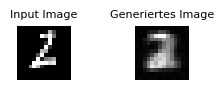

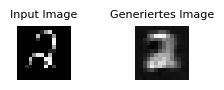

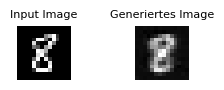

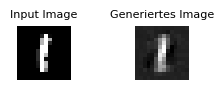

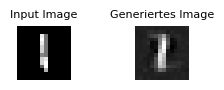

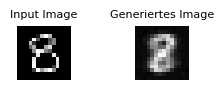

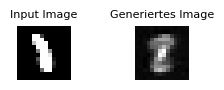

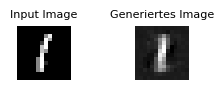

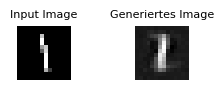

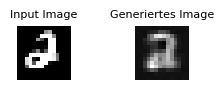

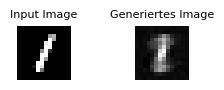

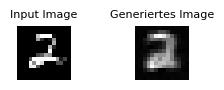

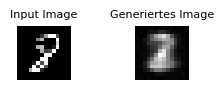

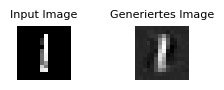

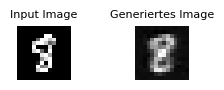

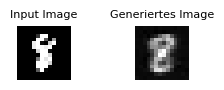

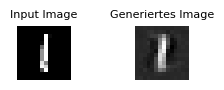

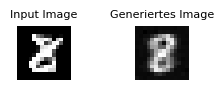

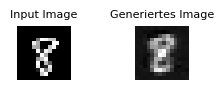

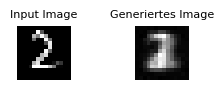

In [5]:
# Eine Auswahl an Encodierten Bildern erzeugen und ausgeben. Im Vergleich zu den Input-Bildern.

dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

bilderzahl = 20

for i in range(0,bilderzahl):
    x_reconst = reg.predict(X_test[i].reshape(-1,196))
    plt.figure(figsize=(280 / float(dpi), 70 / float(dpi)))
    plt.subplot(1,2,1)
    plt.axis('off')
    plt.imshow(X_test[i].reshape(14,14), 'gray')
    plt.title('Input Image', fontsize = 8)
    plt.subplot(1,2,2)
    plt.axis('off')
    plt.imshow(x_reconst.reshape(14,14), 'gray')
    plt.title('Generiertes Image', fontsize = 8)
    plt.show()

(50, 2)
(2,)
[-0.24172296  0.22026052]


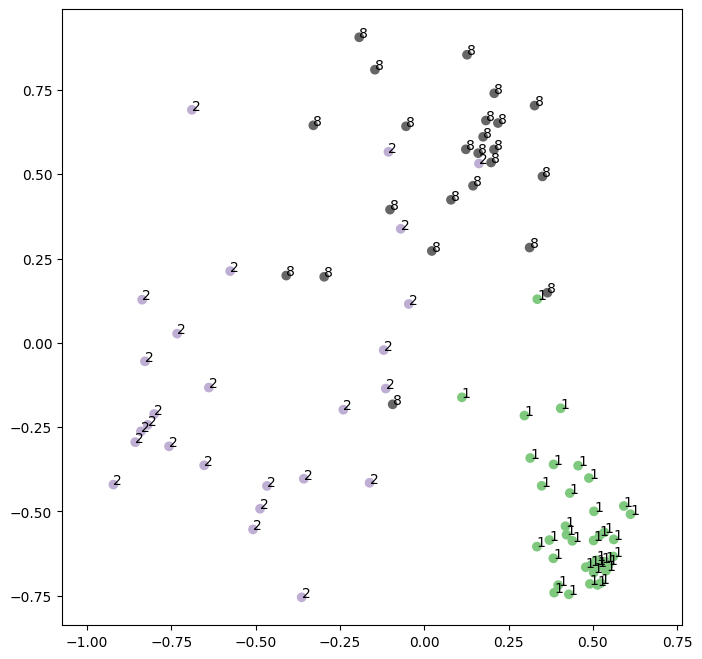

In [6]:
# Darstellung 'Latent Space': Für den gesamten X_test-Datensatz das neuronale Netz Schicht für Schicht
# bis zum Bottleneck berechnen und zu jedem Bild die Outputs der beiden Neuronen als Plot darstellen

data = np.asmatrix(X_test)
encoder1 = data*reg.coefs_[0] + reg.intercepts_[0]
encoder1 = (np.exp(encoder1) - np.exp(-encoder1))/(np.exp(encoder1) + np.exp(-encoder1))

encoder2 = encoder1*reg.coefs_[1] + reg.intercepts_[1]
encoder2 = (np.exp(encoder2) - np.exp(-encoder2))/(np.exp(encoder2) + np.exp(-encoder2))
    
latent = encoder2*reg.coefs_[2] + reg.intercepts_[2]
print(reg.coefs_[2].shape)
print(reg.intercepts_[2].shape)
print(reg.intercepts_[2])
latent = (np.exp(latent) - np.exp(-latent))/(np.exp(latent) + np.exp(-latent))

test_latent = np.asarray(latent)
latent_x_y = np.insert(test_latent, 2, y_test, axis = 1)

plt.figure(figsize = (8,8))
plt.scatter(latent_x_y[:,0],latent_x_y[:,1], c = latent_x_y[:,2], cmap = 'Accent')
plt.axis('equal')

for i, txt in enumerate(latent_x_y[:,2]):
    plt.annotate(np.uint8(txt), (latent_x_y[i,0], latent_x_y[i,1]))

plt.show()

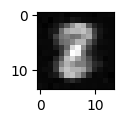

In [12]:
# Neue Bilder erzeugen: im 'Latent Space den Output der beiden Bottleneck-Neuronen willkürlich'
# erzeugen und die Decoderneuronen damit durchrechnen. 

new_data = np.asmatrix([0.1, 0.1])
decoder3 = new_data*reg.coefs_[3] + reg.intercepts_[3]

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 3 berechnet.
decoder3 = (np.exp(decoder3) - np.exp(-decoder3))/(np.exp(decoder3) + np.exp(-decoder3))

# Tangens-Hyperbolicus-Funktion: Anhand der Gewichtungen wird der Wert der Aktivierungsfunktion für Layer 4 berechnet.
decoder4 = decoder3*reg.coefs_[4] + reg.intercepts_[4]
decoder4 = (np.exp(decoder4) - np.exp(-decoder4))/(np.exp(decoder4) + np.exp(-decoder4))

reconst = decoder4*reg.coefs_[5] + reg.intercepts_[5]
reconst = (np.exp(reconst) - np.exp(-reconst))/(np.exp(reconst) + np.exp(-reconst))

reconst = np.asarray(reconst)

testbild = reconst.reshape(14,14)
plt.figure(figsize = (1,1))
plt.imshow(testbild, cmap='gray', aspect=1)
plt.show()